<a href="https://colab.research.google.com/github/jrippe2020/happiness-python-analysis-repo/blob/main/A_Predictive_Analysis_On_Happiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Background

#### Welcome to my portfolio project on happiness!
**Background & Rationale:** This project explores factors that influence happiness around the world using both the World Happiness Report (scraped from this [site](https://data.worldhappiness.report/table)) and my own happiness dataset collected over 9 months. My background is in neuroscience and I have always loved learning about how individual people and cultures nurture happiness & what we can learn about what it means to live a meaningful life through our different approaches. I hope this analysis is as interesting to read as it was to conduct. *Happy Reading!*

**Data Sources:** World Happiness Report, my own happiness dataset

**Project Objective:**
1.   To analyze factors that predict happiness ranking ***(global factors)***
2.   To analyze the impact of different habits on my own happiness rating ***(individual habits)***


**Date Range:**
* World Happiness Report: 2015-2025 (score refresh = annual)
* My happiness dataset: July 2025-March 2026 (score refresh = daily)

***BONUS:*** If you found this analysis interesting, I built an [interactive dashboard](https://datastudio.google.com/u/0/reporting/d5e423dc-24b2-422f-8fd0-6e90f5622991/page/G78tF) in Data Studio (Looker Studio) if you'd like to play around with the data yourself! I find this super fun myself - and I'd love to hear from you if you draw any interesting conclusions! :)


## Importing Relevant Libraries

In [1]:
# I'm going to import the relevant libraries I'll use for my analyses
!pip install plotly-calplot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.formula.api import ols

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import linear_model

from plotly_calplot import calplot

# World Happiness Report | What predicts happiness around the world?

## Data Dictionary


#### **World Happiness Report Dataset:**
- `Year`: The year the that country was ranked at the current ranking out of all countries included in that year.
- `Happiness Ranking`: The ranking of each country in terms of life evaluation. The current year's ranking for a given country is based on an average of life evaluation scores from the previous 3 years. This variable can be used as a proxy of life evaluation.
- `Country`: An individual country.
- `Region`, `Subregion`, & `Intermediate-region`: The area of the world that country belongs to.

**The following items have been defined by the [World Happiness Report](https://data.worldhappiness.report/map):**
- `Life evaluation`: The global ranking is based on a single life evaluation question: Please imagine a ladder with steps numbered from 0 at the bottom to 10 at the top. The top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you. On which step of the ladder would you say you personally feel you stand at this time? This variable can be used as a proxy of happiness ranking.
- `Change avg`: The change in average life evaluation since the first ranking was published in 2012.
- `Inequality`: The standard deviation of life evaluation scores. Countries with a higher standard deviation have a wider spread of scores which indicates greater inequality in happiness.
- `Social support`: If you were in trouble, do you have relatives or friends you can count on to help you whenever you need them, or not? The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country in which respondents felt they had the most social support and the max ranking is the country in which respondents felt they had the least social support.
- `GDP per capita`: In terms of Purchasing Power Parity adjusted to constant 2017 international dollars, taken from the World Development Indicators by the World Bank. The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country with the highest GDP per capita that year and the max value is the country with the lowest GDP per capita that year.
- `Healthy life expectancy`: Based on data from the World Health Organization Global Health Observatory. The most recent data is from 2021. The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country in which respondents had the highest expectancy of a healthy life and the max value is the country in which respondents had the lowest expectancy of a healthy life.
- `Freedom`: Are you satisfied or dissatisfied with your freedom to choose what you do with your life? The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country where respondents felt they had the most freedom to choose what to do with their lives and the max value is the country where respondents felt they had the least freedom to choose what to do with their lives.
- `Generosity`: Have you donated money to a charity in the past month? The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country where the most respondents indicated they had donated in the past month and the max value is the country where the least respondents indicated they had donated in the past month. **Same as Donated.**
- `Perception of corruption`: The average of two questions: “Is corruption widespread throughout the government or not?” and “Is corruption widespread within businesses or not?” Where data for government corruption are missing, the perception of business corruption is used as the overall corruption-perception measure. The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 the country in which the most respondents indicated corruption was low and the max value is the country in which the most respondents indicated corruption was high.
- `Positive emotions`: The national average of binary responses (0=no, 1=yes) about three emotions experienced on the previous day: laughter, enjoyment, and interest. The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country with the highest frequency of positive emotions experienced by respondents on the previous day and the max value is the country with the lowest frequency of positive emotions experienced by respondents on the previous day.
- `Negative emotions`: The national average of binary responses (0=no, 1=yes) about three emotions experienced on the previous day: worry, sadness, and anger. The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country with the lowest frequency of negative emotions experienced by respondents on the previous day and the max value is the country with the highest frequency of negative emotions experienced by respondents on the previous day.
- `Donated`: Have you donated money to a charity in the past month? The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country where the most respondents indicated they had donated in the past month and the max value is the country where the least respondents indicated they had donated in the past month. **Same as Generosity.**
- `Volunteered`: Have you volunteered your time to an organisation in the past month? The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country in which the most respondents had volunteered their time to an organization in the past month and the max value is the country in which the least respondents had volunteered their time to an organization in the past month.
- `Helped a stranger`: Have you helped a stranger or someone you didn't know who needed help in the past month? The score represents how that country ranks for that variable amongst all countries surveyed that year where 1 is the country in which the most respondents had helped a stranger in the past month and the max value is the country in which the least respondents had helped a stranger in the past month.


## Descriptive Statistics & EDA

### Descriptive Statistics

In [2]:
dataframe_whr = pd.read_csv('whr.csv')

In [3]:
# Let's take a look at this dataframe through the first 10 rows of data to see all the available columns
dataframe_whr.head(11)

,Year,Happiness Ranking,Country,Region,Subregion,Intermediate-region,Life evaluation,Change avg,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
0,2025,1.0,Finland,Europe,Northern Europe,NaN,7.764,0.375,2.0,9.0,17.0,18.0,11.0,46.0,2.0,39.0,11.0,46.0,71.0,96.0
1,2025,2.0,Iceland,Europe,Northern Europe,NaN,7.540,0.185,4.0,1.0,9.0,4.0,5.0,8.0,28.0,7.0,8.0,8.0,78.0,118.0
2,2025,3.0,Denmark,Europe,Northern Europe,NaN,7.539,−0.154,13.0,2.0,6.0,15.0,17.0,27.0,3.0,11.0,41.0,27.0,43.0,61.0
3,2025,4.0,Costa Rica,Americas,Latin America and the Caribbean,Central America,7.439,0.182,37.0,30.0,49.0,29.0,3.0,90.0,52.0,5.0,24.0,90.0,75.0,16.0
4,2025,5.0,Sweden,Europe,Northern Europe,NaN,7.255,−0.225,7.0,11.0,10.0,7.0,20.0,17.0,4.0,53.0,36.0,17.0,97.0,80.0
5,2025,6.0,Norway,Europe,Northern Europe,NaN,7.242,−0.413,9.0,3.0,3.0,5.0,9.0,10.0,8.0,17.0,34.0,10.0,24.0,83.0
6,2025,7.0,Netherlands,Europe,Western Europe,NaN,7.223,−0.289,1.0,25.0,7.0,NaN,32.0,7.0,13.0,47.0,31.0,7.0,22.0,104.0
7,2025,8.0,Israel,Asia,Western Asia,NaN,7.187,−0.114,5.0,18.0,26.0,9.0,95.0,44.0,34.0,108.0,40.0,44.0,65.0,107.0
8,2025,9.0,Luxembourg,Europe,Western Europe,NaN,7.063,0.009,20.0,37.0,2.0,NaN,22.0,32.0,9.0,43.0,51.0,32.0,36.0,110.0
9,2025,10.0,Switzerland,Europe,Western Europe,NaN,7.018,−0.632,28.0,28.0,4.0,6.0,35.0,14.0,5.0,27.0,29.0,14.0,34.0,116.0


In [4]:
# Next, let's look at the average ranking by country for each metric

# Country
dataframe_whr_dropped_regions = dataframe_whr[dataframe_whr.columns.drop(['Year', 'Region', 'Intermediate-region', 'Subregion', 'Change avg'])]
dataframe_whr_country_avg = dataframe_whr_dropped_regions.groupby('Country').mean().sort_values('Happiness Ranking').round(2)

dataframe_whr_country_avg

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Country,,,,,,,,,,,,,,
Finland,1.73,7.71,3.91,5.91,17.73,18.91,6.00,44.00,3.18,30.36,12.18,44.00,51.18,83.00
Denmark,2.09,7.58,15.00,6.73,7.82,17.00,9.45,22.27,2.73,13.18,29.36,22.27,58.00,67.91
Iceland,3.27,7.52,8.70,1.10,10.70,5.30,7.50,6.00,34.80,9.50,9.20,6.00,61.44,103.56
Norway,5.09,7.41,12.45,9.27,3.36,7.55,6.27,12.82,7.09,14.64,30.18,12.82,32.36,89.73
Netherlands,5.73,7.38,1.55,22.36,7.64,NaN,29.45,7.55,11.45,43.00,27.64,7.55,30.82,101.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Burundi,148.67,3.34,120.00,141.00,140.00,114.00,121.00,137.00,22.00,83.00,107.00,137.00,60.00,119.00
Rwanda,149.43,3.39,61.60,129.60,130.40,105.20,24.40,84.00,2.40,42.20,87.80,84.00,78.60,105.20
South Sudan,150.40,3.27,134.67,136.00,NaN,133.33,138.00,75.33,51.33,108.00,140.33,75.33,38.67,41.00


In [5]:
# Let's look at the average ranking by region for each metric as well

# Region
dataframe_whr_dropped_countries = dataframe_whr[dataframe_whr.columns.drop(['Year', 'Country', 'Subregion', 'Intermediate-region','Change avg'])]
dataframe_whr_region_avg = dataframe_whr_dropped_countries.groupby('Region').mean().sort_values('Happiness Ranking').round(2)

dataframe_whr_region_avg

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Region,,,,,,,,,,,,,,
Oceania,10.23,7.18,20.68,14.32,20.50,17.41,23.23,11.64,10.00,31.36,31.82,11.64,16.23,44.59
Europe,41.87,6.35,37.68,35.62,33.09,34.78,60.08,52.78,64.12,72.79,48.37,52.78,82.47,94.19
Americas,48.70,6.13,87.78,57.16,65.98,59.28,52.73,79.78,69.13,24.68,78.23,79.78,56.94,51.52
Asia,81.41,5.32,66.05,75.31,69.04,61.09,65.46,61.61,63.06,82.14,67.37,61.61,75.55,76.83
Africa,118.97,4.39,99.80,109.14,108.62,104.66,94.06,92.70,71.18,79.42,90.65,92.70,59.12,46.77


In [6]:
# Lastly, let's take a closer look at average ranking by subregion

# Subregion
dataframe_whr_dropped_regions_countries = dataframe_whr[dataframe_whr.columns.drop(['Year', 'Country', 'Region', 'Intermediate-region','Change avg'])]
dataframe_whr_subregion_avg = dataframe_whr_dropped_regions_countries.groupby('Subregion').mean().sort_values('Happiness Ranking').round(2)

dataframe_whr_subregion_avg

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Subregion,,,,,,,,,,,,,,
Australia and New Zealand,10.23,7.18,20.68,14.32,20.50,17.41,23.23,11.64,10.00,31.36,31.82,11.64,16.23,44.59
Western Europe,14.43,7.03,14.40,29.39,11.92,17.84,41.54,27.42,14.73,46.82,35.71,27.42,39.89,97.32
Northern America,15.55,7.00,33.45,26.32,11.55,38.45,51.36,15.00,26.27,29.50,65.41,15.00,18.68,29.27
Northern Europe,18.93,7.00,18.59,13.18,18.05,25.52,31.34,38.80,26.72,40.05,25.05,38.80,69.00,89.92
Latin America and the Caribbean,51.90,6.05,93.61,60.47,72.03,61.54,52.88,86.73,73.73,24.17,79.61,86.73,61.04,53.91
Southern Europe,61.34,5.85,55.33,50.92,43.81,30.12,78.56,61.75,91.32,100.50,79.40,61.75,101.85,102.51
Eastern Europe,61.35,5.84,47.28,38.73,45.83,60.95,80.57,78.58,100.88,88.16,41.55,78.58,100.82,89.53
Eastern Asia,63.06,5.82,43.92,56.73,40.31,29.98,84.84,60.73,51.66,82.49,23.10,60.73,77.13,106.41
Central Asia,66.50,5.73,44.14,32.35,88.18,76.41,36.02,51.14,52.37,70.29,26.24,51.14,64.45,73.92


In [7]:
# I'm also going to check for nulls - I want to be aware of nulls in each column so I can account for them in later calculations
# For the WHR dataframe, the columns Intermediate-region and Healthy life expectancy have the most nulls so I'll keep that in mind when considering my later comparisons using those metrics

dataframe_whr.isna().sum()

,0
Year,0
Happiness Ranking,5
Country,0
Region,0
Subregion,11
Intermediate-region,1006
Life evaluation,5
Change avg,58
Inequality,134
Social support,136


In [8]:
# I'm also going to take a look at the count of those nulls in comparison to the entire dataframe
dataframe_whr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      1639 non-null   int64  
 1   Happiness Ranking         1634 non-null   float64
 2   Country                   1639 non-null   object 
 3   Region                    1639 non-null   object 
 4   Subregion                 1628 non-null   object 
 5   Intermediate-region       633 non-null    object 
 6   Life evaluation           1634 non-null   float64
 7   Change avg                1581 non-null   object 
 8   Inequality                1505 non-null   float64
 9   Social support            1503 non-null   float64
 10  GDP per capita            1474 non-null   float64
 11  Healthy life expectancy   1394 non-null   float64
 12  Freedom                   1471 non-null   float64
 13  Generosity                1501 non-null   float64
 14  Percepti

### Exploratory Data Analysis

#### I have 6 main questions I'd like to answer as part of my exploratory data analysis:

1. How highly does each category correlate with happiness ranking?
2. What are the top 10 happiest countries on average over the last 10 years?
3. What are the bottom 10 countries in terms of happiness on average over the last 10 years?
4. Which countries rank the highest on average for each category over the last 10 years?
5. How does one's expectancy of living a healthy life correlate to their satisfaction with life? Does this look different depending on where in the world you live?
6. How has the US changed in rankings for different factors over the last 10 years?

##### Question 1: How highly does each category correlate with happiness ranking?

*Results*
* Happiness ranking was most highly correlated with how a country ranked for **GDP per capita** (ρ = 0.82), **social support** (ρ = 0.79), and **healthy life expectancy** (ρ = 0.77).
* Happiness ranking was least correlated with how a country ranked for **volunteering** (ρ = 0.08) and **helping a stranger** (ρ = -0.21).

*Discussion*
* It is perhaps unsurprisingly that GDP per capita was the most highly correlated factor with happiness ranking. Intuitively, it makes sense that respondents residing in a wealthier country are more likely to feel their life is going well. What is more interesting to me is the fact that social support was the next most highly correlated factor with happiness ranking. This means that respondents living in a country where interdependence (i.e., relying on one's community) is valued are more likely to be happier with their lives. Countries that consistently rank in the top 10 including Denmark, Finland, and Norway are known to have robust social welfare infrastructure (Kangas & Kvist, 2018), so it seems plausable that bolstering a country's resources for caring for individual citizens from a social support perspective could translate into individuals feeling they can rely on others more easily. While this may seem like a stretch to make this connection, research has shown that as people feel more able to rely on their government to support their basic needs, trust in others increases (Delhey & Newton, 2005; Rothstein & Uslaner, 2011).

In [9]:
# I'm going to find the correlations between each predictor and happiness ranking using Spearman's rank correlation
# Note: I'm using Spearman's rank correlation because I'm working with country rankings (ordinal data)! If I had access to the raw data I would be doing Pearson's
for column_name in dataframe_whr.columns.drop(['Year','Life evaluation', 'Country', 'Region', 'Subregion', 'Intermediate-region', 'Change avg', 'Donated']):
  spearmans_correlation_coefficient = dataframe_whr[[column_name, 'Happiness Ranking']].corr(method='spearman').iloc[0,1]
  print(column_name,':', spearmans_correlation_coefficient.round(2))

Happiness Ranking : 1.0
Inequality : 0.57
Social support : 0.79
GDP per capita : 0.82
Healthy life expectancy  : 0.77
Freedom : 0.56
Generosity : 0.47
Perception of corruption : 0.34
Positive emotions : 0.48
Negative emotions : 0.51
Volunteered : 0.09
Helped a stranger : -0.18


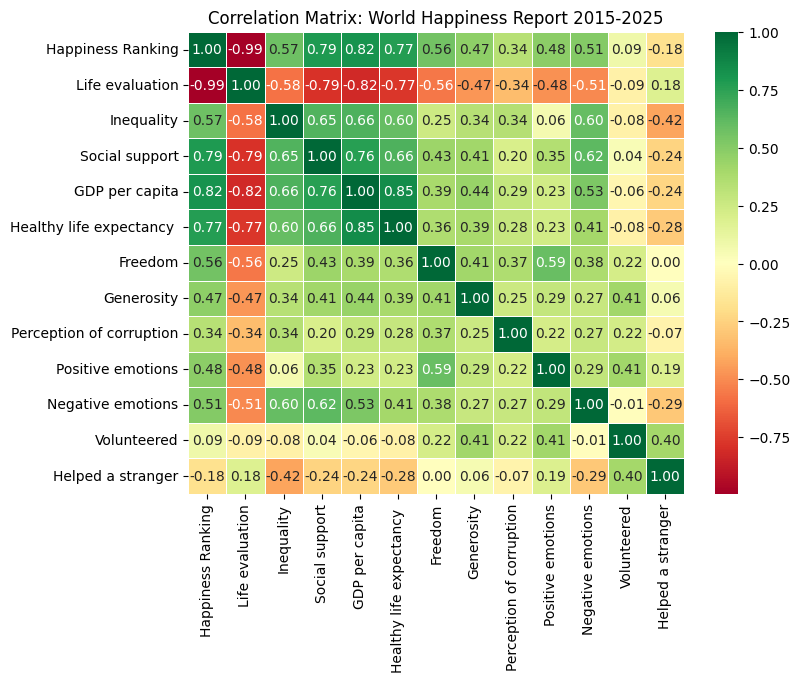

In [10]:
# Let's visualize these relationships with a correlation matrix
relevant_columns_only = dataframe_whr.columns.drop(['Year', 'Country', 'Region', 'Subregion', 'Intermediate-region', 'Change avg', 'Donated'])

matrix = dataframe_whr[relevant_columns_only].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: World Happiness Report 2015-2025')
plt.show()

##### Question 2: What are the top 10 happiest countries on average over the last 10 years?

*Results*
* The top 10 happiest countries in order were: Finland *(happiest)*, Denmark, Iceland, Norway, Netherlands, Switzerland, Sweden, New Zealand, Israel, and Australia *(10th happiest)*.

*Discussion*
* It's notable that 7 out of the top 10 countries are located in Northern & Western Europe. While copious research exists analyzing what makes countries in this region so happy, the main factors this dataset seems to point to are particularly high (i.e., good) rankings for inequality, social support, & freedom and low rankings for perception of corruption.
* Israel, New Zealand, and Australia had worse rankings than the top 7 countries for many of the factors stated above but tended to rank higher than European countires for generosity, volunteering, and helping a stranger.

In [11]:
# I've already created a new dataframe where I've grouped by country, so I'll simply use head() and tail() to answer which countries are in the top 10 and which are in the bottom 10 on average

# Top 10 Happiest Countries
dataframe_whr_country_avg.head(10)

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Country,,,,,,,,,,,,,,
Finland,1.73,7.71,3.91,5.91,17.73,18.91,6.00,44.00,3.18,30.36,12.18,44.00,51.18,83.00
Denmark,2.09,7.58,15.00,6.73,7.82,17.00,9.45,22.27,2.73,13.18,29.36,22.27,58.00,67.91
Iceland,3.27,7.52,8.70,1.10,10.70,5.30,7.50,6.00,34.80,9.50,9.20,6.00,61.44,103.56
Norway,5.09,7.41,12.45,9.27,3.36,7.55,6.27,12.82,7.09,14.64,30.18,12.82,32.36,89.73
Netherlands,5.73,7.38,1.55,22.36,7.64,NaN,29.45,7.55,11.45,43.00,27.64,7.55,30.82,101.60
Switzerland,6.09,7.35,18.00,19.64,4.55,7.09,21.36,22.18,5.91,31.82,15.64,22.18,34.82,114.55
Sweden,6.91,7.33,13.91,19.64,12.82,9.09,11.00,16.55,4.73,28.45,18.73,16.55,94.73,82.73
New Zealand,9.36,7.20,16.82,10.36,25.55,21.00,19.64,12.55,5.45,22.09,22.91,12.55,12.73,49.64
Israel,9.64,7.24,15.55,22.36,29.27,7.18,76.09,31.55,47.27,100.18,59.36,31.55,58.73,87.36


##### Question 3: What are the bottom 10 countries in terms of happiness on average over the last 10 years?

*Results*
* The bottom 10 happiest countries in order were: Central African Republic *(least happy)*, Syria, South Sudan, Rwanda, Burundi, Afghanistan, Haiti, Yemen, Tanzania, and Botswana *(10th to the least happy)*.

*Discussion*
* The countries that ranked the lowest (worst) for happiness were dispersed over a larger range of continents than the happiest countries, with 3 countries from the Middle East, 1 country from the Caribbean, and 6 countries from Africa represented.
* Countries that ranked the least happy tended to have low rankings for GDP per capita, freedom, and social support and high rankings for perception of corruption.
* Multiple countries in this list ranked highly for helping a stranger including South Sudan (41/161) and Syria (32/161). Haiti also ranked highly for generosity (22/161).

In [12]:
# Bottom 10 Happiest Countries
dataframe_whr_country_avg.tail(10)

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Country,,,,,,,,,,,,,,
Botswana,142.00,3.54,114.22,99.11,65.11,117.20,68.56,130.33,74.78,77.11,65.22,130.33,98.67,18.89
Tanzania,142.82,3.59,118.09,114.45,117.45,100.73,56.09,50.73,33.00,65.45,36.36,50.73,100.82,86.73
Yemen,143.00,3.61,82.86,84.29,133.80,107.60,128.57,140.29,73.40,137.57,71.71,140.29,135.14,111.57
Haiti,143.50,3.69,96.50,133.75,118.75,120.25,137.50,21.75,53.00,110.00,106.75,21.75,30.25,66.25
Afghanistan,146.91,2.53,16.50,137.38,124.88,123.60,137.12,120.38,98.00,136.38,125.12,120.38,106.62,96.12
Burundi,148.67,3.34,120.00,141.00,140.00,114.00,121.00,137.00,22.00,83.00,107.00,137.00,60.00,119.00
Rwanda,149.43,3.39,61.60,129.60,130.40,105.20,24.40,84.00,2.40,42.20,87.80,84.00,78.60,105.20
South Sudan,150.40,3.27,134.67,136.00,NaN,133.33,138.00,75.33,51.33,108.00,140.33,75.33,38.67,41.00
Syria,151.75,3.36,132.00,140.00,110.00,126.00,135.00,65.00,35.00,141.00,141.00,65.00,69.00,32.00


##### Question 4: Which countries rank the highest on average for each category over the last 10 years?

*Results*

The country ranked best for each category was as follows:
* "Happiness Ranking" (overall): Finland
* "Inequality" (least inequality perceived): Netherlands
* "Social support": Iceland
* "GDP per capita": Luxembourg
* "Healthy life expectancy": Belize
* "Freedom": Cambodia
* "Generosity": Indonesia
* "Perception of corruption" (least corruption perceived): Singapore
* "Positive emotions": Guatemala
* "Volunteered": Indonesia
* "Helped a stranger": Liberia

*Discussion*
* While the top countries for happiness ranking were primarily countries in Europe, these findings emphasize that different countries all over the world excel in different predictors of happiness.

In [13]:
# I can again use my dataframe where countries are grouped to answer this question

for column_name in dataframe_whr_country_avg.columns.drop('Donated'):
  if column_name in ['Life evaluation']:
    idx_min = dataframe_whr_country_avg[column_name].idxmax()
    print(f'The top country for the category "{column_name}" is: {idx_min}')
  else:
    idx_max = dataframe_whr_country_avg[column_name].idxmin()
    print(f'The top country for the category "{column_name}" is: {idx_max}')


The top country for the category "Happiness Ranking" is: Finland
The top country for the category "Life evaluation" is: Finland
The top country for the category "Inequality" is: Netherlands
The top country for the category "Social support" is: Iceland
The top country for the category "GDP per capita" is: Luxembourg
The top country for the category "Healthy life expectancy " is: Belize
The top country for the category "Freedom" is: Cambodia
The top country for the category "Generosity" is: Indonesia
The top country for the category "Perception of corruption" is: Singapore
The top country for the category "Positive emotions" is: Guatemala
The top country for the category "Negative emotions" is: Taiwan Province of China
The top country for the category "Volunteered" is: Indonesia
The top country for the category "Helped a stranger" is: Liberia


##### Question 5: How does one's expectancy of living a healthy life correlate to their satisfaction with life? Does this look different depending on where in the world you live?

*Results*
* Respondents living in countries in Latin America and the Caribbean had similar ratings for how satisfied they were with their lives as respondents in Western Europe despite ranking lower on average for expectancy of a healthy life.
* Countries in Southern Asia tended to have highly disparate healthy life expectancy and life evaluation rankings, indicating larger disparities across the region than in other regions.

*Discussion*
* All regions followed a general trend where the higher the country ranked for expectancy of a healthy life, the more satisfied respondents were with their lives. This emphasizes the importance of investing in public health for a happy population.

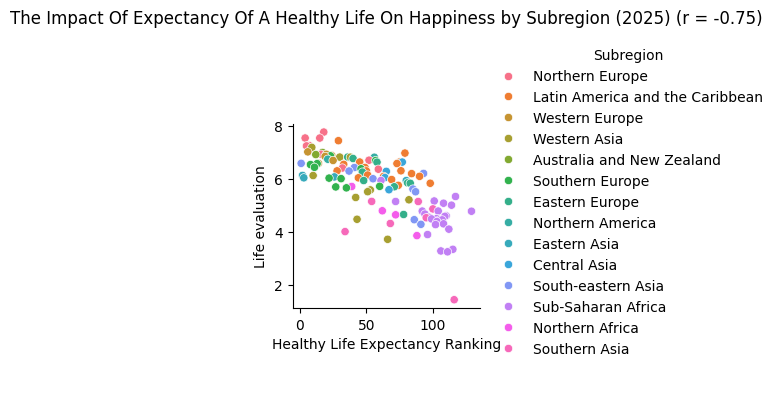

In [14]:
dataframe_whr_2025 = dataframe_whr[dataframe_whr['Year'] == 2025]

correlation_coefficient_hle = dataframe_whr_2025['Healthy life expectancy '].corr(dataframe_whr_2025['Life evaluation'], method='spearman')

sns.pairplot(dataframe_whr[dataframe_whr['Year'] == 2025], hue='Subregion', x_vars='Healthy life expectancy ', y_vars='Life evaluation', kind='scatter')
plt.title(f'The Impact Of Expectancy Of A Healthy Life On Happiness by Subregion (2025) (r = {correlation_coefficient_hle:.2f})', y=1.5)
plt.xlabel('Healthy Life Expectancy Ranking')
plt.show()

##### Question 6: How has the US changed in rankings for different factors over the last 10 years?

*Results*
* The US's rankings for GDP per capita and healthy life expectancy remained steady over the last 10 years.
* The US's ranking for freedom, however, dropped substantially between 2020-2022.
* Rankings for social support followed a similar pattern to rankings for freedom.

*Discussion*
* It's possible that COVID was the main driving force behind US respondents feeling that had lost their sense of freedom to make choices with their lives in the early 2020s.
* The pattern with social support and freedom was notable. My interpretation is that, as respondents' sense of support within their community decreases, so does their perception of being free to make choices in their lives.


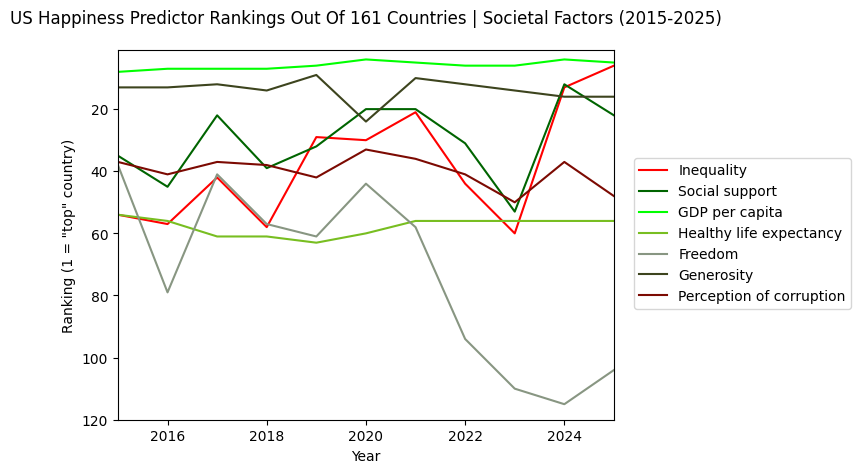

In [15]:
# I'll create a US only version of my dataframe
US_only = dataframe_whr[dataframe_whr['Country'] == 'United States']

# And then I'll make 2 time series line charts; 1 for societal factors (healthy life expectancy, social support, freedom, GDP per capita, inequality, and perception of corruption)

# Societal Factors
sns.lineplot(US_only, x='Year', y='Inequality', label='Inequality', color = 'red')
sns.lineplot(US_only, x='Year', y='Social support', label='Social support', color = '#006400')
sns.lineplot(US_only, x='Year', y='GDP per capita', label='GDP per capita', color = '#00FF00')
sns.lineplot(US_only, x='Year', y='Healthy life expectancy ', label='Healthy life expectancy', color = '#78be21')
sns.lineplot(US_only, x='Year', y='Freedom', label='Freedom', color = '#889682')
sns.lineplot(US_only, x='Year', y='Generosity', label='Generosity', color = '#3D441E')
sns.lineplot(US_only, x='Year', y='Perception of corruption', label='Perception of corruption', color = '#7C0A02')

plt.xlim(2015, 2025)
plt.ylim(1, 120)

plt.legend(loc=(1.04, 0.3))
plt.gca().invert_yaxis()
plt.title(f'US Happiness Predictor Rankings Out Of 161 Countries | Societal Factors (2015-2025)', y=1.05)
plt.xlabel('Year')
plt.ylabel('Ranking (1 = "top" country)')
plt.show()

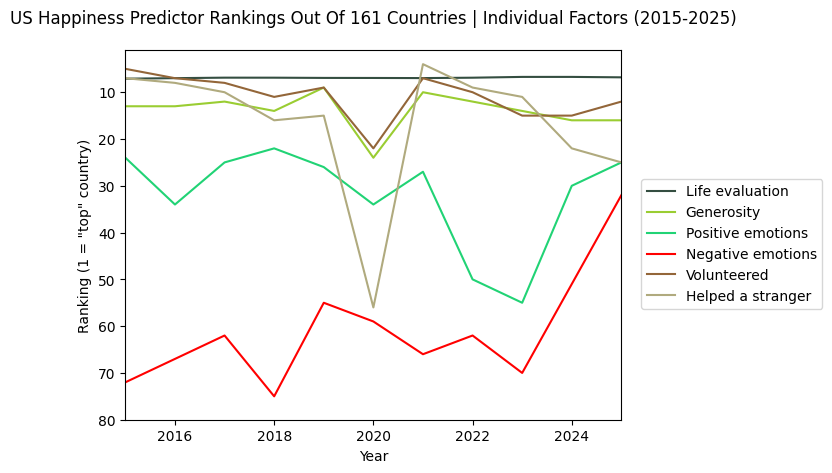

In [16]:
# And 1 for individual factors (life evaluation, generosity, helped a stranger, volunteered, positive emotions, negative emotions)

# Individual Factors
sns.lineplot(US_only, x='Year', y='Life evaluation', label='Life evaluation', color = '#344E41')
sns.lineplot(US_only, x='Year', y='Generosity', label='Generosity', color = '#9ACD32')
sns.lineplot(US_only, x='Year', y='Positive emotions', label='Positive emotions', color = '#21D375' )
sns.lineplot(US_only, x='Year', y='Negative emotions', label='Negative emotions', color = 'red')
sns.lineplot(US_only, x='Year', y='Volunteered', label='Volunteered', color = '#936639')
sns.lineplot(US_only, x='Year', y='Helped a stranger', label='Helped a stranger', color = '#B0AA7E')

plt.xlim(2015, 2025)
plt.ylim(1, 80)

plt.legend(loc=(1.04, 0.3))
plt.gca().invert_yaxis()
plt.title(f'US Happiness Predictor Rankings Out Of 161 Countries | Individual Factors (2015-2025)', y=1.05)
plt.xlabel('Year')
plt.ylabel('Ranking (1 = "top" country)')
plt.show()

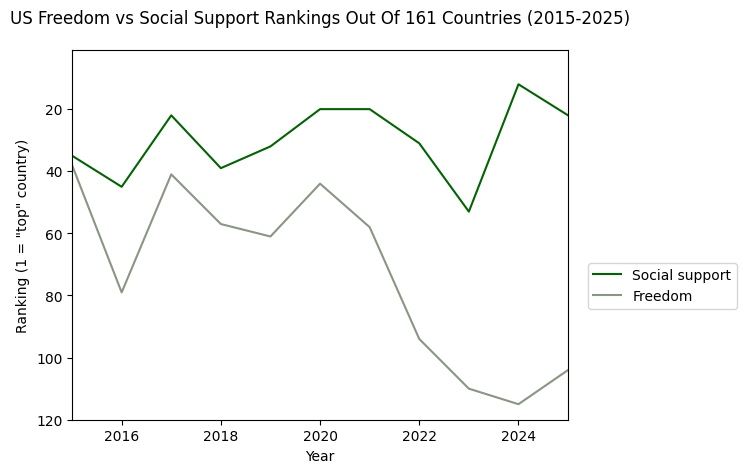

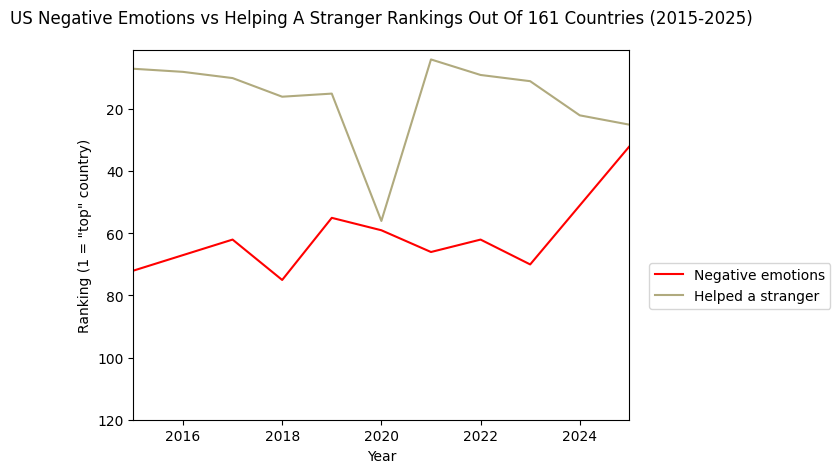

In [17]:
# Let's look at 2 of these factors more closely

# Freedom vs social support

sns.lineplot(US_only, x='Year', y='Social support', label='Social support', color = '#006400')
sns.lineplot(US_only, x='Year', y='Freedom', label='Freedom', color = '#889682')

plt.xlim(2015, 2025)
plt.ylim(1, 120)

plt.legend(loc=(1.04, 0.3))
plt.gca().invert_yaxis()
plt.title(f'US Freedom vs Social Support Rankings Out Of 161 Countries (2015-2025)', y=1.05)
plt.xlabel('Year')
plt.ylabel('Ranking (1 = "top" country)')
plt.show()

# Interpretation: As respondents' sense of support within their community decreases, so does their perception of being free to make choices in their lives.


# Negative emotions vs helping a stranger

sns.lineplot(US_only, x='Year', y='Negative emotions', label='Negative emotions', color = 'red')
sns.lineplot(US_only, x='Year', y='Helped a stranger', label='Helped a stranger', color = '#B0AA7E')

plt.xlim(2015, 2025)
plt.ylim(1, 120)

plt.legend(loc=(1.04, 0.3))
plt.gca().invert_yaxis()
plt.title(f'US Negative Emotions vs Helping A Stranger Rankings Out Of 161 Countries (2015-2025)', y=1.05)
plt.xlabel('Year')
plt.ylabel('Ranking (1 = "top" country)')
plt.show()

# Interpretation: As repondents' report less time spent helping others, negative emotions increase.

## Hypothesis Testing

#### **Guiding Question:** What factors best explain variation in how people feel their lives are going?

#### **Introduction:**
Previous research has shown that factors such as social support and freedom to make one's own choices are significant predictors of happiness around the world (Helliwell & Putnam, 2004; Lim & Putnam, 2010; Inglehart et al., 2008). Additionally, individuals living in high GDP per capita countries tend to report higher life satisfaction (Frey & Stutzer, 2002). This project seeks to understand how these factors as well as additional predictors as identified by the World Happiness Report impact individuals' life evaluation and country overall happiness rankings around the world.

#### **Hypotheses:**
- *H0:* There is no statistically significant relationship between life evaluation and rankings for inequality, freedom, generosity, perception of corruption, positive emotions, negative emotions, volunteered, or helped a stranger. H0: β1 = β2 = … = βk = 0
- *H1:* There is a statistically significant relationship between life evaluation and rankings for inequality, freedom, generosity, perception of corruption, positive emotions, negative emotions, volunteered, or helped a stranger. H1: β1 = β2 = … = βk ≠ 0
#### **Methods:**
*Multiple Linear Regression Model*
* *Dependent Variable:* Life evaluation
* *Independent Variables:* inequality, freedom, generosity, perception of corruption, positive emotions, negative emotions, volunteered, and helped a stranger
* *Significance Level:* 𝜶 = 0.05

y = β0+β1X1+β2X2+β3X3+β4X4+⋯+βnXn

Where y = life evaluation & each independent variable (X) is multiplied by it's coefficient (β)

#### **Results:**
* It was found that 55.1% of the variation in life evaluation can be explained by 5 of the 7 independent variables included in the model (R^2 = 0.551, F(462, 7) = 80.85, *p* < .001).
* The results of the model indicated that **generosity** and **helping a stranger** were not statistically significant predictors of variation in life evaluation (*p* > .05). However, all other factors contributed meaningfully to the variance in life evaluation observed.
* The predictors that had the greatest influence on life evaluation were how a country ranked for **positive emotions** (β = -0.0155, *p* < .001) and **freedom** (β = -0.0095, *p* < .001).
* Additionally, **perception of corruption** (β = 0.003, p < .05), **negative emotions** (β = 0.0038, *p* < .001), and **volunteering** (β = 0.0048, *p* < .001) were found to significantly predict life evaluation.

#### **Discussion:**
* A multiple linear regression analysis was conducted to evaluate the influence of individual predictors on life evaluation when controlling for other factors. Specifically, I wanted to evaluate the prediction of life evaluation (i.e., how well a person feels their life is going from 0-10) from how the country they live in ranks for inequality, freedom, generosity, perception of corruption, positive emotions, negative emotions, volunteering, and helping a stranger. GDP per capita, social support, and healthy life expectancy were removed from the model given their high multicollinearity which reduced model accuracy.
* The most fascinating finding to me was that as a country's rank for volunteering increased (i.e., got worse), so did life evaluation. This means that cultures where life evaluation was high were also those with respondents who volunteered less! This relates back to helping a stranger which, While non-significant, showed a similar pattern. My interpretation is that it may be the case that those in countries where there is less stability or which are higher in conflict may rely on others more than respondents in more stable countries.
* Additionally, it was interesting to see that generosity and helping a stranger did not significantly predict how a person felt about how their life was going. It could be that these behaviors are so innate to human nature in general that how a country ranks for these may fluctuate more than other rankings like GDP per capita which tend to be quite stable.


#### **Limitations:**
* A very important caveat to keep in mind: here, I'm working with ranks, not the underlying raw data (ordinal data rather than the raw, continuous data). This means I'm losing magnitude information; a country ranked number 2 vs a country ranked number 3 may not have the same distance in terms of magnitude as a country ranked 70th and a country ranked 71st for a given variable.
* Since I don't have access to the raw data, it's impossible to know whether the top ranked countries have more similar scores for a given variable than the bottom ranked countries. Therefore, I have tried to be cautious with my interpretations of coefficients by interpreting these values as directional (strength) indicators only.
* The hypotheseis testing below should be considered as approximate given the limitations of the data used.




In [18]:
# I have 1 continuous variable I'd like to predict (life evaluation) and multiple predictor independent variables which are categorical (ordinal). These variables are all on the same scale since they are ranks, so we don't need to apply standardization before fitting our model.
# Given the types of data I'm working with, I'm going to use multiple linear regression

# I know that sklearn uses a binary tree and therefore cannot handle nulls. Since my nulls are a small percentage of my data, I'm going to go ahead and drop the affected rows
dataframe_whr_nonulls = dataframe_whr.dropna()

In [19]:
# Now, I'm going to split my dataframe by my dependent variable (life evaluation) and my independent variables (my categories stated above)
# I'll use uppercase X for my iv_df and lowercase y for my dv_df
# Additionally, I know that GDP per capita, social support, and healthy life expectancy were highly correlated and therefore could pose a problem with multicollinearity. I'm going to drop these columns to improve the accuracy of my model.

X = dataframe_whr_nonulls[['Inequality', 'Freedom', 'Generosity', 'Perception of corruption', 'Positive emotions', 'Negative emotions', 'Volunteered', 'Helped a stranger']]
y = dataframe_whr_nonulls['Life evaluation']

In [20]:
# Now, I'm going to use StatsModels to fit a multiple linear regression model to my data and identify which of my predictor variables explains the most variance in life evaluation

X = sm.add_constant(X)
est = sm.OLS(y, X).fit()
est.summary()

# Interpretation:
# R^2 = 0.551 --> 55% of the variance in life evalutation can be explained by the the predictors included in this model
# Prob (F-statistic) < .05 --> The F statistic observed is unlikely to have occured by chance 95% of the time (5% risk of type 1 error). Since this is significant, we can interpret our model as useful enough to explain a statistically significant proportion of variance in life evaluation. Put simply, there is evidence of linear relationships between the predictors and the target variable.
# coef values (negative) --> As the ranking of a country goes up (i.e., becomes worse since a ranking of 1 = best and a bottom ranking = worst), life evaluation goes down (i.e., satisfaction with one's life decreases). For example: as freedom ranking decreases (becomes better), life evaluation increases
# coef values (positive) --> As the ranking of a country goes down (i.e., becomes better since a ranking of 1 = best and a bottom ranking = worst), life evaluation goes down (i.e., satisfaction with one's life decreases). For example: as negative emotions ranking decreases (becomes worse), life evaluation decreases
# P>|t| (p values) < .05 --> The T statistic observed is unlikely to have occured by chance 95% of the time (5% of type 1 error). If a predictor has a p value < .05, this indicates that that predictor meaningfully contributes to predicting life evaluation, even after controlling for the effects of all other predictors. The predictors for which we have signficant p values are: freedom, perception of corruption, positive emotions, negative emotions, and volunteered.
# Omnibus, Durbin-Watson, Jarque-Bera, Skew, and Kurtosis measures are assessing normality of residuals of each predictor, skew of distributions, tail heaviness, and autocorrelation. All look reasonable in this model.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life evaluation   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     72.59
Date:                Sat, 09 May 2026   Prob (F-statistic):           9.10e-77
Time:                        19:31:31   Log-Likelihood:                -495.36
No. Observations:                 470   AIC:                             1009.
Df Residuals:                     461   BIC:                             1046.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        6.2686      0.191     32.768      0.000       5.893       6.644
Inequality                  -0.0032      0.001     -2.679      0.008      -0.006      -0.001
Freedom                     -0.0096      0.001     -7.839      0.000      -0.012      -0.007
Generosity                  -0.0019      0.001     -1.425      0.155      -0.005       0.001
Perception of corruption     0.0027      0.001      2.236      0.026       0.000       0.005
Positive emotions           -0.0155      0.001    -13.408      0.000      -0.018      -0.013
Negative emotions            0.0046      0.001      4.247      0.000       0.002       0.007
Volunteered                  0.0037      0.001      2.770      0.006       0.001       0.006
Helped a stranger            0.0008      0.001      0.692      0.489      -0.001       0.003
==============================================================================
Omnibus:                       27.627   Durbin-Watson:                   1.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               34.072
Skew:                          -0.521   Prob(JB):                     3.99e-08
Kurtosis:                       3.808   Cond. No.                     1.27e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.27e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Predictive Modeling

#### **Guiding Question:** What is a person's life evaluation score likely to be based on the country they grew up in and how high that country ranks for each category in the last month?

#### **Methods:**
* *Predictive Model Type:* Multiple Linear Regression
* *Training/Test Split:* 70/30
* *Dependent Variable*: life evaluation (continuous data)
* *Independent Variables*: social support, GDP per capita, healthy life expectancy, inequality, freedom, generosity, perception of corruption, positive emotions, negative emotions, volunteered, and helped a stranger (all categorical [ordinal] data)

y = β0+β1X1+β2X2+β3X3+β4X4+⋯+βnXn

Where y = life evaluation & each independent variable (X) is multiplied by it's coefficient (β)



#### **Results:**
*Overall Model:*
* The model explained **78%** of the variation of life evaluation (R^2 = 0.7798, MSE = 0.2396).

*Three Fictional Country Scenarios Modeled:*
1) The Generous Despite It All Country: A country that ranked low (100) in everything except generosity (ranking = 3) --> **Life evaluation
2) The Good Vibes Country: A country that ranked high (3) in social support, healthy life expectancy, generosity, and positive emotions but low (100) in everything else
3) The Chaotic Neutral Country: A country that ranked high (3) for GDP per capita, freedom, and positive emotions and low (100) for everything else

A respondent living in the **Chaotic Neutral Country** was predicted to have the highest satisfaction with their life (6.78/10).

*Impact Of Each Category On Life Satisfaction Modeled:*
* In line with the trend observed during hypothesis testing, residing in a country that ranks highly (low overall) for **GDP per capita** was predicted to result in the highest life evaluation score. Interestingly, the model predicted experiencing positive emotions as more important (2nd most important) to life evaluation than social support (4th most important), with healthy life expectancy staying in third most important.
* In line with the trend observed during hypothesis testing, the average respondent residing in a country that ranks highly (low overall) for **GDP per capita** was predicted to be the most satisfied with their life (6.23/10) when their country of resident was middle of the pack (ranked 75th) for all other categories.
* Interestingly, the model predicted experiencing **positive emotions** in the last day as more important (2nd most important, predicted life evaluation score = 5.86/10) to life evaluation than **social support** (4th most important, predicted life evaluation score = 5.77/10), with **healthy life expectancy** staying in third most important (predicted life evaluation score = 5.8/10).
* Experiencing **negative emotions** in the last day were predicted to result in the lowest predicted life evaluation score (4.83/10).


#### **Discussion:**
* A multiple linear regression model was chosen to predict the average respondent's life evaluation score on a scale from 0-10 depending on changes to each independent variable. Specifically, I wanted to evaluate the prediction of life evaluation (i.e., how well a person feels their life is going from 0-10) in 3 fictional countries (the Generous Despite It All Country, the Good Vibes Country and the Chaotic Neutral Country) as well as model the life evaluation score of an average respondent if their country of residence ranked highly for each category.
* Unsurprisingly given the high correlation observed between GDP per capita and happiness rating, GDP per capita was predicted to have the largest impact on how satisfied the average respondent would be with their life.
* It surprised me that helping a stranger was predicted to have the second to least impact on life evaluation; my interpretation is that, in comparison to other factors such as inequality, this factor would not have as large of an impact on the day to day happiness of an individual.


#### **Limitations:**
* A very important caveat to keep in mind: here, I'm working with ranks, not the underlying raw data (ordinal data rather than the raw, continuous data). This means I'm losing magnitude information; a country ranked number 2 vs a country ranked number 3 may not have the same distance in terms of magnitude as a country ranked 70th and a country ranked 71st for a given variable.
* Since I don't have access to the raw data, it's impossible to know whether the top ranked countries have more similar scores for a given variable than the bottom ranked countries. Therefore, I have tried to be cautious with my interpretations of coefficients by interpreting these values as directional (strength) indicators only.
* The results of this predictive model should be considered as approximate given the limitations of the data used.

In [21]:
# Since I'll be using the same methods as in my multiple linear regression hypothesis testing, I will skip some of the explanations. However, I will redefine the dataframes I use and my X and y since I'm going to add GDP per capita, social support, and healthy life expectancy back in.
dataframe_whr_nonulls_2 = dataframe_whr.dropna()
X = dataframe_whr_nonulls_2[['Social support', 'GDP per capita', 'Healthy life expectancy ', 'Inequality','Freedom', 'Generosity', 'Perception of corruption', 'Positive emotions', 'Negative emotions', 'Volunteered', 'Helped a stranger']]
y = dataframe_whr_nonulls_2['Life evaluation']

# I'll be splitting my data into 70% for training and 30% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

regr = linear_model.LinearRegression()
regr.fit(X_train,y_train)

LinearRegression()

In [22]:
# I imported r2_score and mean_squared_error from sklearn.metrics which I'll use here to evaluate the accuracy of my model
pred = regr.predict(X_test)

print('Mean Squared Error:', mean_squared_error(y_test, pred))
print('R-squared:', r2_score(y_test, pred))
# The independent variables included in this model can explain 76.8% of the variation in life evaluation.

Mean Squared Error: 0.23964679203642542
R-squared: 0.7798317035531594


In [23]:
# I'll store my predicted vs actual life evaluation scores in a dataframe
output = pd.DataFrame({
    'Actual Life Evaluation': y_test,
    'Predicted Life Evaluation': pred
})

output.head()

,Actual Life Evaluation,Predicted Life Evaluation
1323,3.582,3.771342
372,5.695,5.964211
1280,4.724,5.090812
1629,3.695,3.853435
1522,6.324,5.832109


In [24]:
# Ok! Now that I've fit my model and assessed how strong it is, let's derive some knowledge from it.

# I'll start with computing the coefficients for my model. I want to understand the factor by which life evaluation changes as a country's ranking in each category increases
print(regr.coef_)

# If we run this, we see that as the ranking for GDP per capita increases (i.e., a country ranks worse for this measure), life evaluation drops by a factor of 1.29e-02x.
# These coefficients are all quite small so it's important to interpret these as directional only

[-6.56611588e-03 -1.29458734e-02 -6.92952495e-03  1.13298830e-03
 -1.97835895e-03  8.39166202e-05 -8.63250884e-04 -7.74785289e-03
  6.53845631e-03 -2.10689516e-03  2.76497557e-03]


In [25]:
# Now, let's make some predictions!

# Prediction 1: The Generous Despite It All country | What would the life evaluation rating be of a country that ranked low (100) in everything except generosity (ranking = 3)?
predicted_happiness_generouscountry = regr.predict([[100, 100, 100, 100, 100, 3, 100, 100, 100, 100, 100]])
print('The Generous Despite It All country:', predicted_happiness_generouscountry.round(2))

# Prediction 2: The Good Vibes county | What would the life evaluation rating be of a country that ranked high (3) in social support, healthy life expectancy, generosity, and positive emotions but low (100) in everything else?
predicted_happiness_goodvibescountry = regr.predict([[3, 100, 3, 100, 100, 3, 100, 3, 100, 100, 100]])
print('The Good Vibes county:', predicted_happiness_goodvibescountry.round(2))

# Prediction 3: The Chaotic Neutral country | What would the life evaluation rating be of a country that ranked high (3) for GDP per capita, freedom, and positive emotions and low (100) for everything else?
predicted_happiness_chaoticneutralcountry = regr.predict([[100, 3, 100, 100, 3, 100, 100, 3, 100, 100, 100]])
print('The Chaotic Neutral country:', predicted_happiness_chaoticneutralcountry.round(2))

The Generous Despite It All country: [4.58]
The Good Vibes county: [6.64]
The Chaotic Neutral country: [6.78]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
# Finally, let's change just 1 factor at a time and see the impact it has on life evaluation. We'll have the high value be 3 and the keep all other values in the middle of the rankings (75)

predicted_happiness_socialsupport = regr.predict([[3, 75, 75, 75, 75, 75, 75, 75, 75, 75, 75]])
predicted_happiness_gdp = regr.predict([[75, 3, 75, 75, 75, 75, 75, 75, 75, 75, 75]])
predicted_happiness_hle = regr.predict([[75, 75, 3, 75, 75, 75, 75, 75, 75, 75, 75]])
predicted_happiness_inequality = regr.predict([[75, 75, 75, 3, 75, 75, 75, 75, 75, 75, 75]])
predicted_happiness_freedom = regr.predict([[75, 75, 75, 75, 3, 75, 75, 75, 75, 75, 75]])
predicted_happiness_generosity = regr.predict([[75, 75, 75, 75, 75, 3, 75, 75, 75, 75, 75]])
predicted_happiness_poc = regr.predict([[75, 75, 75, 75, 75, 75, 3, 75, 75, 75, 75]])
predicted_happiness_posemotions = regr.predict([[75, 75, 75, 75, 75, 75, 75, 3, 75, 75, 75]])
predicted_happiness_negemotions = regr.predict([[75, 75, 75, 75, 75, 75, 75, 75, 3, 75, 75]])
predicted_happiness_volunteered = regr.predict([[75, 75, 75, 75, 75, 75, 75, 75, 75, 3, 75]])
predicted_happiness_has = regr.predict([[75, 75, 75, 75, 75, 75, 75, 75, 75, 75, 3]])

# I'm interested in which categories my model predicts will have the most influence on life evaluation in order so I'm going to create a dataframe with these predictions & sort by life evaluation prediction
category_influence_data = {
    'Category': ['Social support', 'GDP per capita', 'Healthy life expectancy', 'Inequality', 'Freedom', 'Generosity', 'Perception of corruption', 'Positive emotions', 'Negative emotions', 'Volunteered', 'Helped a stranger'],
    'Life evaluation prediction': [predicted_happiness_socialsupport.round(2), predicted_happiness_gdp.round(2), predicted_happiness_hle.round(2), predicted_happiness_inequality.round(2), predicted_happiness_freedom.round(2), predicted_happiness_generosity.round(2), predicted_happiness_poc.round(2), predicted_happiness_posemotions.round(2), predicted_happiness_negemotions.round(2), predicted_happiness_volunteered.round(2), predicted_happiness_has.round(2)]
}

category_influence_df = pd.DataFrame(category_influence_data)

category_influence_df.sort_values('Life evaluation prediction', ascending=False)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

,Category,Life evaluation prediction
1,GDP per capita,[6.23]
7,Positive emotions,[5.86]
2,Healthy life expectancy,[5.8]
0,Social support,[5.77]
9,Volunteered,[5.45]
4,Freedom,[5.44]
6,Perception of corruption,[5.36]
5,Generosity,[5.3]
3,Inequality,[5.22]
10,Helped a stranger,[5.1]


# My Dataset | What predicts my own happiness?

## Data Dictionary


#### **My Dataset:**
- `Date`: The day the happiness rating relates to. All columns with a 'True' value on a date were practiced.
- `Happiness Rating(110)`/`Happiness`: A rating of my happiness that day from 1-10 where 1 is the worst day ever and 10 is the best day of my life.
- `Practiced Fiddle?`/`Fiddle`: A boolean variable. A 'True' value means I practiced the fiddle on that date while a 'False' value means I didn't.
- `Practiced a language?`/`Languages`: A boolean variable. A 'True' value means I practiced a language on that date while a 'False' value means I didn't.
- `Slept 8 hours?`/`Sleep`: A boolean variable. A 'True' value means I slept at least 8 hours the night before that date while a 'False' value means I didn't.
- `Meditated?`/`Meditation`: A boolean variable. A 'True' value means I practiced meditation on that date while a 'False' value means I didn't.
- `Exercised?`/`Exercise`: A boolean variable. A 'True' value means I exercised on that date while a 'False' value means I didn't.


## Descriptive Statistics & EDA

### Descriptive Statistics

#### First, I'm going to take a look at my data & assess nulls

In [143]:
dataframe_jdr = pd.read_csv('jdr.csv')

# Let's take a look at this dataframe with a look at the first 10 rows of data
dataframe_jdr.head(11)

,Date,Happiness Rating (110),Practiced Fiddle?,Practiced a language?,Slept 8 Hours?,Meditated?,Exercised?
0,7/4/2025,7.0,True,False,False,True,True
1,7/5/2025,7.0,False,True,True,False,False
2,7/6/2025,6.5,True,False,False,True,True
3,7/7/2025,7.5,True,True,False,False,False
4,7/8/2025,6.0,False,False,True,False,False
5,7/9/2025,7.5,False,True,False,False,False
6,7/10/2025,8.0,False,False,False,False,False
7,7/11/2025,8.0,False,True,False,False,False
8,7/12/2025,8.0,False,False,True,False,False
9,7/13/2025,8.0,False,False,True,False,False


In [144]:
# Now, I'm going to establish some descriptive stats on my data for the 1 continuous column I have ('Happiness Rating (110)')
dataframe_jdr.describe()

,Happiness Rating (110)
count,260.000000
mean,6.379615
std,1.369020
min,2.000000
25%,6.000000
50%,6.500000
75%,7.000000
max,9.000000


In [145]:
# There are no nulls in this dataframe! Almost like I was the (excellent) respondent!
dataframe_jdr.isna().sum()

,0
Date,0
Happiness Rating (110),0
Practiced Fiddle?,0
Practiced a language?,0
Slept 8 Hours?,0
Meditated?,0
Exercised?,0


In [146]:
# I'd like to know the distribution of my data (i.e., how often did I practice each habit? Was I more consistent with certain habits over others?)
# To do this, I'm going to start by summing the days practiced for each habit while dropping columns I'm not interested in for the moment

for column_name in dataframe_jdr.columns.drop(['Date', 'Happiness Rating (110)']):
  days_practiced = dataframe_jdr[column_name].values.sum()
  print(column_name,':', days_practiced)

Practiced Fiddle? : 87
Practiced a language? : 44
Slept 8 Hours? : 109
Meditated? : 29
Exercised? : 54


In [147]:
# Now, I'm going to transform these results into a dataframe

habit_frequency = {
'Habit': ['Fiddle', 'Languages', 'Sleep', 'Meditation', 'Exercise'],
'Total Days Practiced': [87, 44, 109, 29, 54]
}

habit_frequency_df = pd.DataFrame(habit_frequency)

habit_frequency_df_sorted = habit_frequency_df.sort_values('Total Days Practiced', ascending=False)

/tmp/ipykernel_4696/1519784814.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




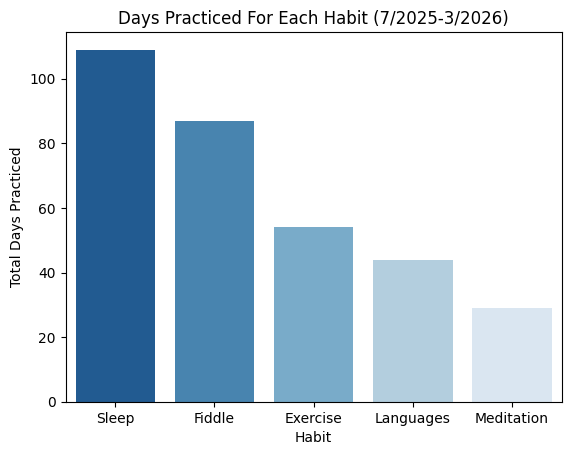

In [148]:
# Finally, I'll plot these sums

sns.barplot(habit_frequency_df_sorted, x='Habit', y='Total Days Practiced', palette='Blues_r')
plt.title(f'Days Practiced For Each Habit (7/2025-3/2026)')
plt.xlabel('Habit')
plt.show()

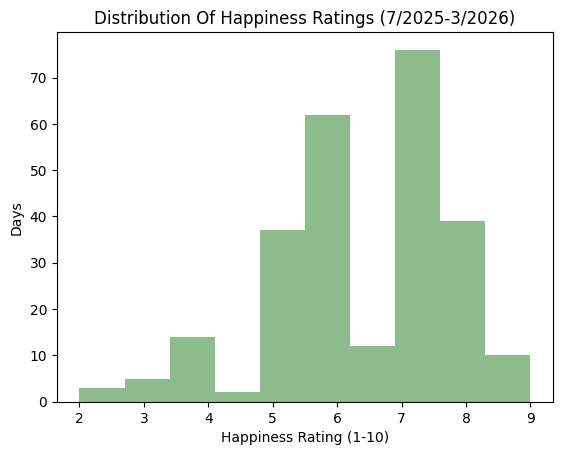

In [149]:
# I'd further like to see the frequency of happiness ratings - was my happiness rating fairly consistent? Did my happiness skew higher or lower on a scale of 1-10?
# I'll create a histogram to look at rating frequency

plt.hist(dataframe_jdr['Happiness Rating (110)'], color='darkseagreen', bins=10)

plt.title('Distribution Of Happiness Ratings (7/2025-3/2026)')
plt.xlabel('Happiness Rating (1-10)')
plt.ylabel('Days')
plt.show()

# We can see that my data are distributed in a bimodal fashion. There are 2 primary peaks: I tended to rate most days either a 6 or 7 out of 10. Since I have more than 30 observations, we know the Central Limit Theorem applies and the means of randomly selected samples of my data will be normally distributed, so I can proceed with statistical testing that relies on assumptions of normality (this will become important later on in this notebook).

In [150]:
# I'm also interested in how my happiness rating is distributed throughout the time I collected data; were there any patterns of particularly high or low mood?
# First, I'm going to change the date column format to %Y-%m-%d so I can use the calplot library
dataframe_jdr['Date'] = pd.to_datetime(dataframe_jdr['Date'])

# Now, I can create a heatmap of happiness ratings throughout my dataframe

fig = calplot(
    dataframe_jdr,
    x='Date',
    y='Happiness Rating (110)',
    colorscale='rdylgn',
    dark_theme=True,
    month_lines_width=2,
    month_lines_color='#FFFFFF'
    )

fig.update_layout(
    title={
        'text': 'Happiness Ratings By Day (7/2025-3/2026)',
        'x': 0.5,
        'y': 1,
        'xanchor': 'center',
        'font': {'size': 20}},
    title_y=.98,
    margin=dict(t=30)
    )

fig.show()

### Exploratory Data Analysis

#### I have 3 main questions I'd like to answer as part of my exploratory data analysis:

1. What are the most commonly practiced habits on days where my happiness rating is in the upper quartile?

2. How well does each habit correlate with my happiness rating?

3. What countries could you assume I might be living in based on my mean happiness rating according to the World Happiness Report?


##### Question 1: What are the most commonly practiced habits on days where my happiness rating is in the upper quartile?

*Results*
* My most commonly practiced habits on days I was the happiest in order were: slept 8 hours, practiced fiddle, exercised, practiced a language, and meditated.

*Discussion*
* This order follows how often I practiced these habits in general, so it seems I wasn't more likely to practice any particular habit when I was happiest (or that any habit increased my happiness rating on a particular day).

In [151]:
# I know the quartiles of my happines rating column from using describe() earlier
# I'm going to slice my dataframe to look at days where my happiness rating was in the 75th percentile (>= 7 out of 10) and create a new dataframe based on those results

upper_quartile_days = dataframe_jdr[dataframe_jdr['Happiness Rating (110)'] >= 7]

In [152]:
# Then, I'm going to count the frequency of each habit practiced on those days while dropping columns I don't need for the moment
for column_name in dataframe_jdr.columns.drop(['Date', 'Happiness Rating (110)']):
  days_practiced = upper_quartile_days[column_name].values.sum()

# I'll make this into a dataframe and order by days practiced so it's easier to see what habits are most commonly practiced on these high happiness rating days

high_happiness_days_data = ({
   'Habit': ['Practiced Fiddle?', 'Practiced a language?', 'Slept 8 Hours?', 'Meditated?', 'Exercised?'],
   'Days Practiced': [40, 25, 51, 14, 27]
})

high_happiness_days_df = pd.DataFrame(high_happiness_days_data).sort_values('Days Practiced', ascending=False)

high_happiness_days_df.head()

# This shows the same pattern as my overall habit frequency - I practiced each habit in the dataframe shown below in the same order, regardless of happiness rating

,Habit,Days Practiced
2,Slept 8 Hours?,51
0,Practiced Fiddle?,40
4,Exercised?,27
1,Practiced a language?,25
3,Meditated?,14


##### Question 2: How does each habit correlate with my happiness rating?

*Results*
* While all correlations between habits and happiness rating were low (-0.1 < ρ < 0.1), the habits that were most highly correlated with happiness rating were practicing a language and exercising.

*Discussion*
* It does not appear that any singular habit was highly correlated with my happiness rating. This indicates that my happiness was relatively stable, regardless of habits practiced. This also indicates that none of these habits were *decreasing* my happiness which is good to know!
* Interestingly, certain habits correlated more strongly with each other than with happiness rating. For example, the correlation between practicing the fiddle and sleeping 8 hours was ρ = 0.19. This may indicate that I was more likely to practice fiddle when I was well rested. However, this is still quite a weak correlation.

In [153]:
# Since I noticed that the total days practiced for some of these habits was too low for a machine learning model used to predict my happiness, I'm going to create a correlation matrix similarly to how I looked at WHR factors

# First, I'm going to transform my boolean data from true/false to 1/0

dataframe_jdr_01_4_bools = dataframe_jdr.replace({True:1, False:0})

/tmp/ipykernel_4696/4116366526.py:5: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [154]:
# Then, I'm going to do a Pearson's correlation for only the relevant columns, create a new dataframe with these result, and sort by correlation

for column_name in dataframe_jdr_01_4_bools.columns.drop(['Date']):
  pearsons_correlation_coefficient = dataframe_jdr_01_4_bools[[column_name, 'Happiness Rating (110)']].corr().iloc[0,1]

happiness_corr_jdr_data = ({
    'Habit': ['Practiced Fiddle?', 'Practiced a language?', 'Slept 8 Hours?', 'Meditated?', 'Exercised?'],
    'Happiness Correlation': [-0.0556, 0.0788, -0.0837, -0.0045, 0.0486]
})

happiness_corr_jdr_df = pd.DataFrame(happiness_corr_jdr_data).sort_values('Happiness Correlation', ascending=False)

happiness_corr_jdr_df

,Habit,Happiness Correlation
1,Practiced a language?,0.0788
4,Exercised?,0.0486
3,Meditated?,-0.0045
0,Practiced Fiddle?,-0.0556
2,Slept 8 Hours?,-0.0837


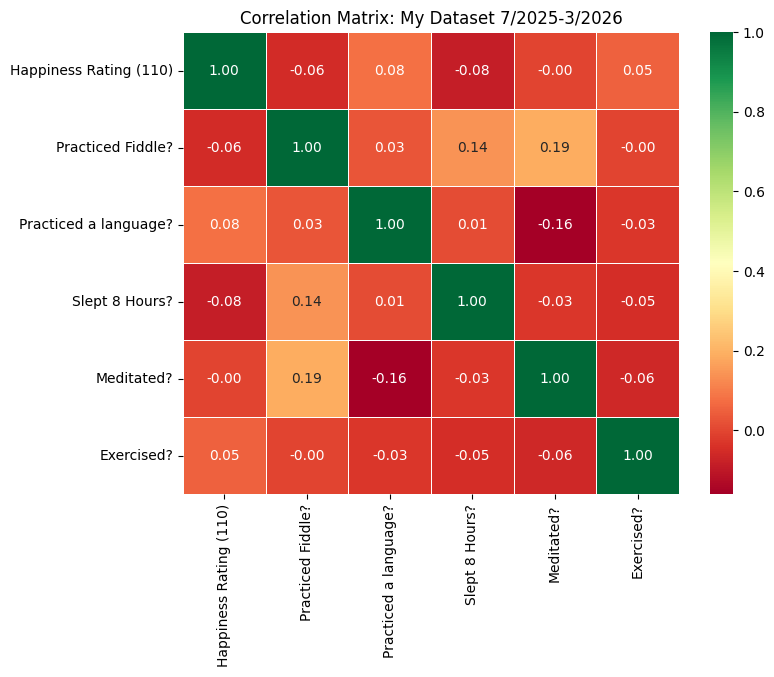

In [155]:
# Let's visualize these relationships with a correlation matrix
relevant_columns_only_jdr = dataframe_jdr_01_4_bools.columns.drop(['Date'])

matrix = dataframe_jdr[relevant_columns_only_jdr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: My Dataset 7/2025-3/2026')
plt.show()

##### Question 3: What countries could you assume I might be living in based on my mean happiness rating according to the World Happiness Report?

*Results*
* My average happiness rating out of 10 was 6.38. One country had the same average life evaluation score: **Chile!**
* When I expanded the range of happiness ratings to a 95% confidence interval there were 23 countries I could have been a respondent in including 1 I've lived in

*Discussion*
* While these metrics were slightly different between the WHR and my dataset, the question I and survey respondents answered was essentially the same: how happy are you with your life? It is interesting to compare my score with averages around the world and consider the impact of my environment on my happiness rating.
* I wonder if you can guess the country from the list of 23 options I have actually lived in! Hint - they love mate, football/soccer, and dulce de leche :)

In [156]:
# I've already calculated my mean happiness rating on a scale of 1-10 but as a refresher:
dataframe_jdr['Happiness Rating (110)'].mean().round(2)

6.38

In [157]:
# Now, I'd like to see which countries have the same mean when we look at life satisfaction on a scale of 1-10
countries_I_could_be_living_in_exact = dataframe_whr_country_avg[dataframe_whr_country_avg['Life evaluation'] == 6.38]

countries_I_could_be_living_in_exact

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Country,,,,,,,,,,,,,,
Chile,35.36,6.38,51.64,52.36,48.55,29.27,78.73,55.0,85.55,20.91,72.18,55.0,92.45,40.91


In [158]:
# If I calculate a 95% confidence interval (+/- 1.96 standard deviations from the mean), I get the following range:

m = dataframe_jdr['Happiness Rating (110)'].mean()
stdv = dataframe_jdr['Happiness Rating (110)'].std(ddof=0)
n = len(dataframe_jdr)

z = stats.norm.ppf(0.975)
e = z * (stdv / np.sqrt(n))
print('Lower bound:', (m - e).round(2), 'Upper bound:', (m + e).round(2))


Lower bound: 6.21 Upper bound: 6.55


In [159]:
# If I look at countries with mean life evaluation in this range, I could potentially be living in any of the following countries:
countries_I_could_be_living_in_approx = dataframe_whr_country_avg[
    (dataframe_whr_country_avg['Life evaluation'] >= 6.21) &
    (dataframe_whr_country_avg['Life evaluation'] <= 6.55)]

countries_I_could_be_living_in_approx

# Fun fact: I actually have lived in one of these countries! I wonder if you can guess which - they love mate, football/soccer, and dulce de leche :)

,Happiness Ranking,Life evaluation,Inequality,Social support,GDP per capita,Healthy life expectancy,Freedom,Generosity,Perception of corruption,Positive emotions,Negative emotions,Donated,Volunteered,Helped a stranger
Country,,,,,,,,,,,,,,
Taiwan Province of China,27.73,6.51,30.64,45.36,21.00,NaN,78.45,46.55,46.82,37.00,1.73,46.55,93.27,85.45
Uruguay,29.18,6.49,61.91,29.55,47.18,45.91,25.00,72.36,27.55,25.00,62.09,72.36,84.18,48.91
Saudi Arabia,29.27,6.49,74.36,51.09,18.82,48.73,45.71,59.00,54.00,48.20,51.82,59.00,96.27,33.00
Singapore,30.09,6.49,12.40,42.30,2.00,1.20,29.40,19.30,1.11,50.40,12.00,19.30,44.30,67.00
Malta,31.55,6.51,40.09,22.55,21.00,10.00,28.00,10.36,45.09,79.45,103.27,10.36,49.18,96.27
Qatar,33.00,6.37,101.00,NaN,2.00,43.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brazil,33.18,6.44,93.27,49.91,63.18,74.73,65.27,77.45,56.73,61.45,96.64,77.45,78.73,59.18
Spain,33.45,6.42,20.36,19.36,27.73,6.91,82.73,49.18,51.91,78.82,87.55,49.18,87.18,72.36
Slovenia,34.91,6.37,39.00,13.91,29.82,22.36,14.18,45.18,76.09,92.18,59.00,45.18,34.91,112.09


## Hypothesis Testing

#### **Guiding Question:** Are happiness rating and habits practiced related?

#### **Introduction:**
Previous research has shown that habits including exercise, meditation, and learning an instrument can improve happiness (Sran et al., 2021; Smith et al., 1995; Zhang et al., 2024). Additionally, the impact of quality sleep on happiness and well-being has been extensively studied (Lajunen et al., 2023). My aim in collecting data on the frequency with which I practiced each of these habits was to attempt to eludicate which of my habits impacted my personal happiness the most.

#### **Hypotheses:**
- *H0:* Happiness rating and the habits practiced are independent.
- *H1:* Happiness rating and at least one habit is not independent.
#### **Methods:**
* *Test:* ANOVA (multi-way)
* *Dependent Variable:* Happiness rating
* *Independent Variables:* Practiced fiddle? Practiced a language? Slept 8 hours? Exercised? Meditated?
* *Significance Level:* 𝜶 = 0.05


#### **Results:**
* It was found that 1.8% of the variation in life evaluation can be explained by the independent variables included in the model (R^2 = 0.018, F(254, 5) = 0.936, *p* = 0.46).
* The results of the model indicate that no individual factor was a significant predictor of variation in my happiness rating (*p* > 0.05)

#### **Discussion:**
* The low R^2 indicates the factors included in the model can only explain a very small proportion of the variance in my happiness ratings. Additionally, no habit was found to significantly predict changes in my happiness rating. My interpretation is that these findings points towards three possibilities:
1. These habits truly do not impact my happiness in any significant way.
2. These habits do impact my happiness but there are other factors in my life that contribute to my happiness rating much more significantly.
3. These habits impact my happiness but the effect is obscured by the nature of these habits being recorded as frequencies (did I practice the habit that day, yes/no) rather than having each habit recorded as a continuous variable (per day: hours of sleep, hours of practice, etc).


#### **Limitations:**
* The primary limitation of working with this dataset was that all of my predictor columns (habits) were boolean in nature. This is because I wanted to design my habit tracker to be something that I could consistently commit to and therefore made it easy and quick to fill out by simply checking off the habits I had practiced and noting my happiness rating for that day. If I had recorded habits as continuous measures (e.g., how many hours of sleep did I get last night? How long did I practice fiddle? How long did I exercise today?) then I could have built a more informative model.
* Additionally, it's important to state that while these are my core habits that I focus on, they are by no means the only habits I practice. It would be impossible to identify and quantify the contribution of every potential confounding variable to my overall happiness rating.

In [160]:
# Firstly, I'm going to rename my column names since they're a bit messy for this next part of my analysis
dataframe_jdr.columns = ['Date', 'Happiness', 'Fiddle', 'Languages', 'Sleep', 'Meditated', 'Exercised']

In [161]:
# Now, I will conduct my multi way ANOVA

# For this analysis I'll be looking at main effects only
model = ols('Happiness ~ C(Fiddle) + C(Languages) + C(Sleep) + C(Meditated) + C(Exercised)**2', data=dataframe_jdr).fit()
anova_table = sm.stats.anova_lm(model, type=2)
print(anova_table)

# We can see from our PR(>F) column (p values) that none of these habits were significant predictors of happiness rating! Go figure!



# I also want to assess my overall model for significance
r2_value = model.rsquared
df_between = model.df_model
df_within = model.df_resid
print('DF between:', df_between)
print('DF within:', df_within)
print('R-squared:', r2_value.round(4))
print('Overall F-statistic:', model.fvalue.round(4))
print('Overall p-value:', model.f_pvalue.round(4))


                 df      sum_sq   mean_sq         F    PR(>F)
C(Fiddle)       1.0    1.502619  1.502619  0.800742  0.371719
C(Languages)    1.0    3.136060  3.136060  1.671198  0.197273
C(Sleep)        1.0    2.899019  2.899019  1.544879  0.215039
C(Meditated)    1.0    0.117316  0.117316  0.062517  0.802763
C(Exercised)    1.0    1.127137  1.127137  0.600648  0.439052
Residual      254.0  476.639811  1.876535       NaN       NaN
DF between: 5.0
DF within: 254.0
R-squared: 0.0181
Overall F-statistic: 0.936
Overall p-value: 0.4582
